# Introducción a DeepXDE: Resolver la ecuación de Poisson 1D

Autor: José Robledo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/teorico_practicos/Semana03_intro_deepxde.ipynb)

## Introducción

En esta notebook vamos a usar una **Physics-Informed Neural Network (PINN)** para resolver una ecuación diferencial con [`DeepXDE`](https://deepxde.readthedocs.io/en/latest/). La idea es convertir un problema clásico de ecuaciones diferenciales en un problema de aprendizaje: en vez de aproximar datos, entrenamos una red para que respete una ley física.

El problema que queremos resolver es la ecuación de Poisson 1D:

$$
\nabla^2 u - f = \frac{d^2u}{dx^2} + \pi^2 \sin(\pi x) = 0,
$$

con $x\in[-1,1]$ y condiciones de contorno de Dirichlet

$$
u(-1) = 0, \qquad u(1)=0.
$$

En este caso conocemos la solución exacta:

$$
u(x) = \sin(\pi x).
$$

Eso convierte este ejemplo en una muy buena puerta de entrada a `DeepXDE`, porque podemos comparar la predicción de la PINN contra la solución analítica y entender qué está aprendiendo la red en cada etapa.

## [`DeepXDE`](https://deepxde.readthedocs.io/en/latest/) 

DeepXDE es una librería de código abierto diseñada para resolver ecuaciones diferenciales utilizando **redes neuronales informadas por física (PINNs)** y otros métodos basados en aprendizaje automático. Permite formular problemas directos e inversos combinando datos y leyes físicas (expresadas como ecuaciones diferenciales) en una misma función de pérdida, evitando la necesidad de mallas tradicionales como en métodos numéricos clásicos. Soporta múltiples backends (TensorFlow, PyTorch, JAX) y ofrece herramientas para definir geometrías, condiciones de contorno e iniciales, así como para entrenar modelos de forma eficiente. Por su flexibilidad, es especialmente útil en problemas donde los datos son escasos pero la física es conocida, como en difusión, elasticidad o ecuaciones de Helmholtz.


El flujo típico de `DeepXDE` consiste en:

1. escribir el residuo de la ecuación,
2. definir la geometría del dominio,
3. imponer las condiciones de contorno (CC),
4. armar el objeto `dde.data.PDE`, donde se combina la geometría, la PDE, las CC, y los puntos de colocación.
5. definir la red neuronal,
6. entrenar el modelo.

## 1. Escribir la física del problema

En `DeepXDE`, la ecuación diferencial se expresa como una función de Python que devuelve el **residuo** de la PDE. Si la red aprendiera exactamente la solución, ese residuo debería valer cero en todo el dominio.

Crearemos una función llamada `pde(x, y)` que recibe:

- `x`: los puntos del dominio,
- `y`: la salida actual de la red evaluada en esos puntos.

In [126]:
import deepxde as dde
import torch
import numpy as np
torch.set_default_device("cpu")

def pde(x, y):
    dy_xx = dde.grad.hessian(y, x)
    return dy_xx + torch.pi**2 * torch.sin(torch.pi * x)

def sol_exacta(x):
    # yo forcé a utilizar torch, pero DeepXDE está diseñado para trabajar con numpy, así que también se podría usar numpy aquí
    if isinstance(x, np.ndarray):
        x = torch.tensor(x, dtype=torch.float32)
    return torch.sin(torch.pi * x).cpu()

In [127]:
dde.grad.hessian?

Signature: dde.grad.hessian(ys, xs, component=0, i=0, j=0)
Docstring:
Compute `Hessian matrix <https://en.wikipedia.org/wiki/Hessian_matrix>`_ H as
H[i, j] = d^2y / dx_i dx_j, where i,j = 0, ..., dim_x - 1.

Use this function to compute second-order derivatives instead of ``tf.gradients()``
or ``torch.autograd.grad()``, because

- It is lazy evaluation, i.e., it only computes H[i, j] when needed.
- It will remember the gradients that have already been computed to avoid duplicate
  computation.

Args:
    ys: Output Tensor of shape (batch_size, dim_y) or (batch_size_out, batch_size,
        dim_y). Here, the `batch_size` is the same one for `xs`, and
        `batch_size_out` is the batch size for an additional/outer dimension.
    xs: Input Tensor of shape (batch_size, dim_x).
    component: `ys[:, component]` is used as y to compute the Hessian.
    i (int): `i`th row.
    j (int): `j`th column.

Returns:
    H[`i`, `j`]. When `ys` has shape (batch_size, dim_y), the output shape is
   

Usamos autodiferenciación para calcular $d^2y/dx^2$ con `dde.grad.hessian` (existe también `dde.grad.gradients` y `dde.grad.jacobian`) y definimos la solución exacta para comparar el resultado del entrenamiento.

In [128]:
dir(dde.grad)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'clear',
 'gradients',
 'gradients_forward',
 'gradients_reverse',
 'hessian',
 'jacobian']

## 2. Definir la geometría del dominio

La geometría le dice a `DeepXDE` dónde vive el problema. Como estamos en una dimensión y el dominio es $[-1,1]$, usamos `dde.geometry.Interval`.

Este objeto no solo representa el intervalo: también será la base para generar puntos interiores, reconocer el borde y construir el problema completo.

In [129]:
geom = dde.geometry.Interval(-1, 1)

Otras geometrías posibles y utiles son

```python
dde.geometry.Rectangle([x_min, y_min], [x_max, y_max]) # plano 2D rectangular
dde.geometry.TimeDomain(t0, t1) # dominio de tiempo
dde.geometry.GeometryXTime(geom, timedomain) # dominio espacio y tiempo
dde.geometry.Cuboid([x_min, y_min, z_min], [x_max, y_max, z_max]) # cubo
dde.geometry.Hypercube(...) # hibercubo
dde.geometry.Disk(center, radius) # disco
dde.geometry.Sphere(center, radius) # esfera
dde.geometry.Polygon(vertices) # poligono
```

In [130]:
dir(dde.geometry)

['CSGDifference',
 'CSGIntersection',
 'CSGUnion',
 'Cuboid',
 'Disk',
 'Ellipse',
 'Geometry',
 'GeometryXTime',
 'Hypercube',
 'Hypersphere',
 'Interval',
 'PointCloud',
 'Polygon',
 'Rectangle',
 'Sphere',
 'StarShaped',
 'TimeDomain',
 'Triangle',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'csg',
 'geometry',
 'geometry_1d',
 'geometry_2d',
 'geometry_3d',
 'geometry_nd',
 'pointcloud',
 'sample',
 'sampler',
 'timedomain']

## 3. Pensar los datos y los puntos de colocación

En una PINN, la ecuación se fuerza sobre un conjunto de puntos del dominio llamados **collocation points** o puntos de colocación. Hay varias maneras de de incluirlos. Es en estos puntos donde se debe cumplir la pérdida física. Para esto vamos a utilizar `num_domain` o `anchors` más adelante en la definición de `PDE`. `num_domain=16` muestreará de manera aleatoria 16 puntos dentro del dominio definido, mientras que `anchors` permitirá definir los puntos específicos donde se debe cumplir.
 
A continuación se generan 10 puntos en el intervalo [−1,0] y se calcula la solución exacta en esos puntos (esto sería los datos observados). Luego, esos pares (x,u) se usan para agregar una pérdida de datos (tipo MSE) que obliga a la red a coincidir con esos valores durante el entrenamiento. 

In [131]:
x_train = np.linspace(-1, 0, 10).reshape(-1, 1)
y_train = sol_exacta(x_train).cpu()
observe_u = dde.icbc.PointSetBC(x_train, y_train, component=0)

Una alternativa a datos equiespaciados que es muy utilizada es la de muestrear de manera hipercubo latino con `LatinHypercube` de scipy

```python
from scipy.stats import qmc

sampler = qmc.LatinHypercube(d=1)
x = sampler.random(n=100)
x_train = torch.tensor(2 * x - 1, dtype=torch.float32)
```

## 4. Imponer condiciones de contorno

Ahora codificamos la información física en el borde del dominio. En este problema necesitamos imponer

$$
y(-1)=0, \qquad y(1)=0.
$$

En `DeepXDE`, una condición de Dirichlet se construye con `dde.DirichletBC`. Para eso definimos:

- una función que detecta si un punto está en el contorno,
- una función que devuelve el valor que queremos imponer sobre ese contorno.

Aunque acá también escribimos explícitamente `x_bc` e `y_bc`, el objeto `bc` es la pieza clave que después usa `DeepXDE` durante el entrenamiento.

In [132]:
x_bc = torch.tensor([[-1.0], [1.0]], dtype=torch.float32).cpu()
y_bc = torch.tensor([[0.0], [0.0]], dtype=torch.float32).cpu()

#  auxiliar para los puntos en el contorno
def contorno(x, en_contorno):
    return en_contorno

# función auxiliar para los valores en el contorno
def func_contorno(x):
    return 0

# definición de las condiciones de contorno del problema de dirichlet
bc = dde.DirichletBC(geom, func_contorno, contorno)

En principio, la función de contorno puede ser más compleja, por ejemplo si quisieramos sólo restringir la condición al contorno izquierdo, podríamos escribir

```python
def borde_izq(x, on_boundary):
    return on_boundary and np.isclose(x[0], -1)
```

o si quisiesemos solo el borde derecho
```python
def borde_izq(x, on_boundary):
    return on_boundary and np.isclose(x[0], 1)
```

## 5. Armar el problema para `DeepXDE`

El objeto `dde.data.PDE` junta en un solo lugar todo lo necesario para entrenar:

- la geometría,
- la ecuación diferencial,
- las condiciones de contorno,
- cuántos puntos interiores y de borde usar.

En este ejemplo usaremos los `10` datos observados, `16` puntos de colocación, y `2` puntos de contorno. Además pasamos `solution=sol_exacta`, que es opcional, para que `DeepXDE` pueda reportar una métrica contra la solución analítica.

In [133]:
data = dde.data.PDE(geometry=geom,
                    pde=pde,
                    bcs=[observe_u, bc],
                    num_domain=16, # puntos para entrenar, puntos de colocación internos
                    num_boundary=2,
                    solution=sol_exacta,
                    num_test=100 # puntos para evaluar, calcular métricas
                    )

## 6. Elegir la red neuronal

Una PINN sigue siendo una red neuronal estándar, pero entrenada con una función de pérdida informada por física. Acá usamos una red totalmente conectada (`FNN`) con:

- 1 entrada: la coordenada $x$,
- 3 capas ocultas de 50 neuronas,
- 1 salida: la aproximación de $y(x)$.

La activación `tanh` suele funcionar bien en PINNs porque es suave y facilita el cálculo de derivadas. La inicialización `Glorot normal` ayuda a arrancar el entrenamiento en una escala razonable.

In [134]:
# una entrada, una salida, y 3 capas ocultas de 50 neuronas cada una
capas = [1] + [50]*3 + [1]
# Función de activación tangente hiperbólica
activacion = "tanh"
# Inicialización de los pesos con la distribución Glorot normal
inicializacion = "Glorot normal"
# definición de la  red neuronal
red = dde.nn.FNN(capas, activacion, inicializacion)

## 7. Compilar y entrenar el modelo

Acá aparecen dos objetos centrales de `DeepXDE`:

- `dde.Model(data, red)`: combina el problema físico con la red,
- `compile(...)`: define el optimizador y las métricas.

Durante el entrenamiento, la pérdida mezcla el error en el residuo de la ecuación y el error en las condiciones de contorno. Si todo va bien, ambos deberían bajar.

In [135]:
modelo = dde.Model(data, red)
modelo.compile("adam", lr=0.001, metrics=["l2 relative error"])

loss_hist, train_state = modelo.train(epochs=4000)

Compiling model...
'compile' took 0.000176 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [4.28e+01, 4.20e-01, 1.81e-03]    [4.84e+01, 4.20e-01, 1.81e-03]    [9.65e-01]    
1000      [5.50e-04, 5.84e-08, 2.80e-07]    [5.45e-04, 5.84e-08, 2.79e-07]    [4.79e-04]    
2000      [1.08e-04, 3.50e-08, 8.93e-08]    [2.12e-04, 3.50e-08, 8.94e-08]    [2.18e-04]    
3000      [5.29e-04, 6.97e-06, 3.67e-05]    [7.60e-04, 6.97e-06, 3.67e-05]    [5.67e-03]    
4000      [5.15e-05, 5.95e-08, 2.37e-07]    [1.48e-04, 5.96e-08, 2.37e-07]    [5.80e-04]    

Best model at step 4000:
  train loss: 5.18e-05
  test loss: 1.49e-04
  test metric: [5.80e-04]

'train' took 3.330816 s



Como definimos una condición de contorno más la condición física, se imprimen tres funciones de costo.

```python 
Step      Train loss              Test loss               Test metric   
0         [4.28e+01, 4.20e-01, 1.81e-03]    [4.84e+01, 4.20e-01, 1.81e-03]    [9.65e-01]    
```

`4.28e+01` corresponde a la pérdida MSE (siempre primer elemento) con respecto a los datos

`4.20e-01` corresponde a la pérdida física en los puntos de colocación.

`1.81e-03` corresponde a la pérdida con condición de contorno `bc`. que le pasamos a `PDE(bcs=bc)`. 

Como agregamos un conjunto de datos de prueba y pasamos `metrics=["l2 relative error"]` a `model.compile`, imprime la métrica de prueba `Test metric=9.65e-01`.

Podemos graficar rápidamente utilizando la funcionalidad del paquete:

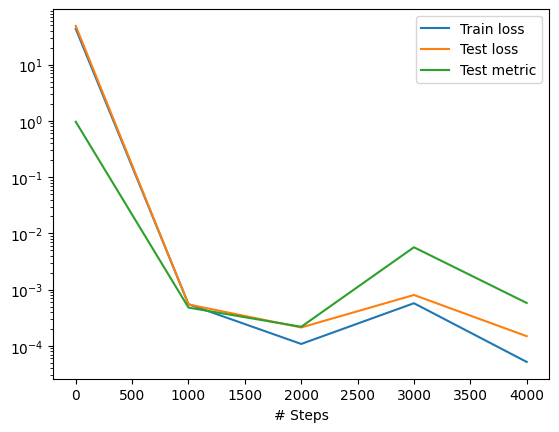

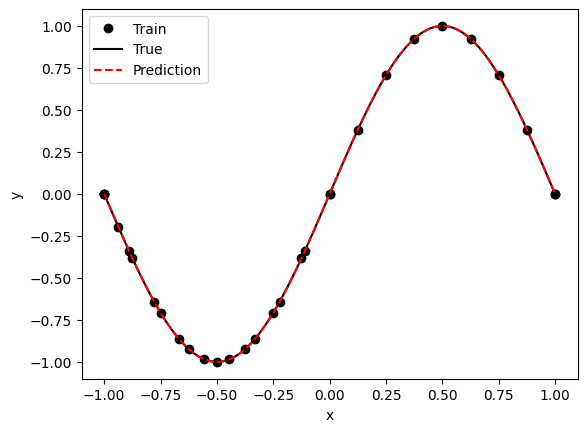

In [136]:
dde.saveplot(loss_hist, train_state, issave=False, isplot=True)

Podemos extraer los datos y hacer nuestras figuras propias

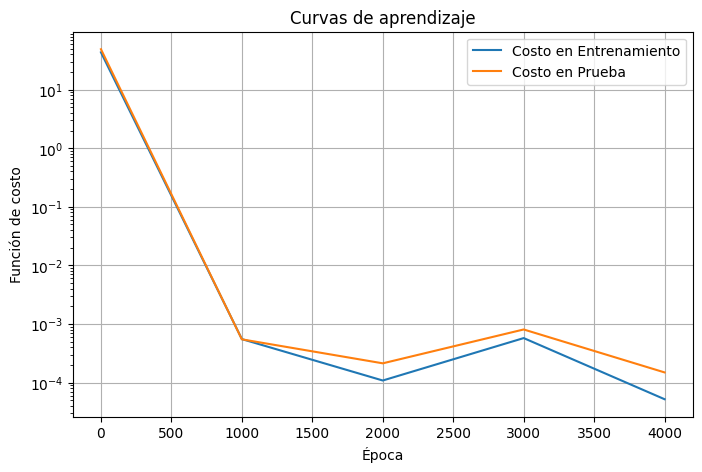

In [137]:
import matplotlib.pyplot as plt
import numpy as np

train_loss = np.array(loss_hist.loss_train)
test_loss = np.array(loss_hist.loss_test)
steps = np.array(loss_hist.steps)

plt.figure(figsize=(8,5))
plt.plot(steps, train_loss.sum(axis=1), label="Costo en Entrenamiento")
plt.plot(steps, test_loss.sum(axis=1), label="Costo en Prueba")
plt.yscale("log")
plt.xlabel("Época")
plt.ylabel("Función de costo")
plt.title("Curvas de aprendizaje")
plt.legend()
plt.grid(True)
plt.show()

## 8. Comparar dentro del dominio de entrenamiento

Primero evaluamos la PINN en puntos del intervalo $[-1,1]$, que es donde realmente está definido el problema.

Acá conviene mirar:

- si la curva azul sigue la forma sinusoidal,
- si respeta los valores en el borde,
- si la diferencia visual con la solución exacta parece pequeña.

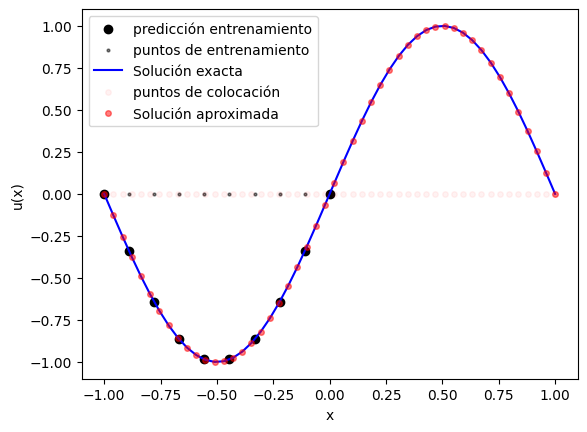

In [158]:
x = geom.uniform_points(50, True)
X_domain = data.train_x[:data.num_domain]
y_pred_train = modelo.predict(x_train)
y_exact_train = sol_exacta(x_train)

y_pred = modelo.predict(x)
y_exact = sol_exacta(x).cpu()
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(x_train, y_pred_train, color='black', label="predicción entrenamiento")
plt.scatter(x_train, np.zeros_like(x_train), color='black', label="puntos de entrenamiento", alpha=0.5, s=4)
plt.plot(x, y_exact, 'b', label="Solución exacta")
plt.plot(x, np.zeros_like(x), 'or', label="puntos de colocación", alpha=0.05, ms=4)
plt.plot(x, y_pred, 'or', label="Solución aproximada", alpha=0.5, ms=4)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.show()

## 9. Qué pasa fuera del dominio

En la siguiente celda extrapolamos la solución a $[-2,2]$. Esto es interesante porque muestra una lección práctica importante: una PINN aprende bien donde fue entrenada y donde se impuso la física, pero **no necesariamente** fuera de ese dominio.

> Pregunta para pensar: si el modelo se desvía fuera de $[-1,1]$, ¿eso significa que entrenó mal, o simplemente que nunca le pedimos respetar la ecuación allí?

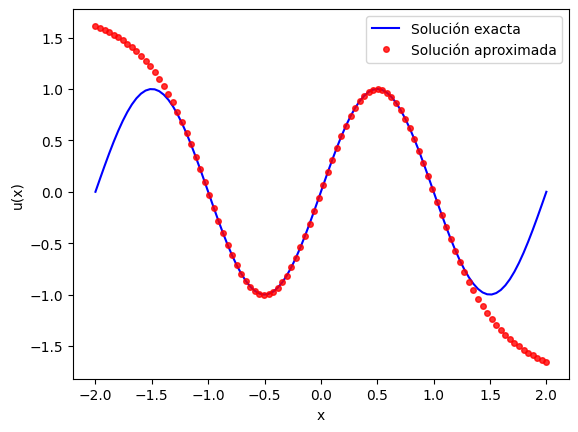

In [162]:
x = torch.linspace(-2,2,100).reshape(-1,1).cpu()
y_pred = modelo.predict(x)
y_exact = sol_exacta(x).cpu()
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x, y_exact, 'b', label="Solución exacta")
plt.plot(x, y_pred, 'or', label="Solución aproximada", alpha=0.8, ms=4)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.show()

## Bibliografía y recursos

- [Documentación oficial de DeepXDE](https://deepxde.readthedocs.io/)
- [Video Youtube de `elastropy`](https://www.youtube.com/watch?v=h1HF3bctoxk&list=PLM7DTyYjZGuLmg3f6j40fEF18jyQmYsC2&index=5)
- [Paper original de PINNs de Raissi, Perdikaris y Karniadakis](https://doi.org/10.1016/j.jcp.2018.10.045)